# Inverse mixed PINN for 2D linear elastostatics

The goal is to approximate two displacement components and three stress components on

$$
\Omega=(0,1)^2,
$$

while the Lamé parameters $\lambda$ and $\mu$ are unknown trainable parameters. Five separate neural networks approximate

$$
u_{x,\theta},\qquad u_{y,\theta},\qquad \sigma_{xx,\theta},\qquad \sigma_{yy,\theta},\qquad \sigma_{xy,\theta}.
$$

Their outputs are collected as

$$
\mathbf q_\theta(x,y)=
\begin{bmatrix}
u_{x,\theta} & u_{y,\theta} & \sigma_{xx,\theta} & \sigma_{yy,\theta} & \sigma_{xy,\theta}
\end{bmatrix}^{\mathsf T}.
$$

For the synthetic inverse experiment, the hidden true values are $\lambda_{\mathrm{true}}=1$ and $\mu_{\mathrm{true}}=1/2$. The exact displacement is

$$
u_{x,\mathrm{exact}}(x,y)=\cos(2\pi x)\sin(\pi y),
\qquad
u_{y,\mathrm{exact}}(x,y)=\frac{Q}{4}\sin(\pi x)y^4,
\qquad Q=4.
$$

## Strong formulation

The infinitesimal-strain tensor, plane-strain constitutive law, and equilibrium equation are

$$
\boldsymbol\varepsilon(\mathbf u)=\frac12\left(\nabla\mathbf u+\nabla\mathbf u^{\mathsf T}\right),
\qquad
\boldsymbol\sigma=\lambda\operatorname{tr}(\boldsymbol\varepsilon)\mathbf I+2\mu\boldsymbol\varepsilon,
\qquad
\nabla\cdot\boldsymbol\sigma+\mathbf f=\mathbf0.
$$

Sparse force-complete observations provide exact or noisy displacement and stress values at the selected supervised coordinates. The known body force is evaluated on the separate PDE collocation grid and enters the equilibrium residual. To preserve the original formulation, no separate boundary-condition loss is added.

## 1. Library imports

In [1]:
import copy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_default_dtype(torch.float64)

/home/eliska/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 2. Configuration

- `USE_NOISY_DATA = False` uses exact observations.
- `USE_NOISY_DATA = True` adds independent zero-mean Gaussian noise with a component-wise standard deviation equal to `NOISE_RELATIVE_STD` times the maximum absolute value of the corresponding field.
- A $100\times100$ uniform Cartesian grid is used for the PDE and constitutive residuals.
- `DATA_POINT_MODE = "random"` samples sparse supervised points uniformly in the domain.
- `DATA_POINT_MODE = "near_boundary"` samples sparse supervised points inside a boundary layer along all four sides.
- Supervised data points are kept outside the PDE mini-batches and the complete sparse data set is used in every Adam step.
- No validation or test split is introduced.
- Four independent-network architectures are trained separately and compared.
- Adam updates $\lambda$, $\mu$, and all neural-network parameters simultaneously.
- Early stopping monitors the total training loss with a patience of 500 epochs.


In [ ]:
USE_NOISY_DATA = True
NOISE_RELATIVE_STD = 0.02

DATA_POINT_MODE = "near_boundary"  # choose "random" or "near_boundary"
N_DATA_TRAIN = 44
BOUNDARY_LAYER_WIDTH = 0.05
assert DATA_POINT_MODE in {"random", "near_boundary"}
assert 0.0 < BOUNDARY_LAYER_WIDTH <= 0.5

LAMBDA_TRUE = 1.0
MU_TRUE = 0.5
Q = 4.0
INITIAL_LAMBDA = 2.0
INITIAL_MU = 2.0

N_SIDE_TRAIN = 100
N_PDE_TRAIN = N_SIDE_TRAIN**2
PDE_BATCH_SIZE = 64
EVALUATION_SIDE = 200

EPOCHS = 10_000
LR = 1e-3
PATIENCE = 500
SEED = 42
PRINT_EVERY = 500

PLOT_ARCHITECTURE = "iv"

torch.manual_seed(SEED)
print(f"True lambda = {LAMBDA_TRUE:.6f}, true mu = {MU_TRUE:.6f}")
print(f"Initial lambda = {INITIAL_LAMBDA:.6f}, initial mu = {INITIAL_MU:.6f}")
print(f"Data mode: {'noisy' if USE_NOISY_DATA else 'exact'}")
print(f"Data-point mode: {DATA_POINT_MODE}")
print(f"Sparse supervised points: {N_DATA_TRAIN}")
if DATA_POINT_MODE == "near_boundary":
    print(f"Boundary-layer width: {BOUNDARY_LAYER_WIDTH:.3f}")


True lambda = 1.000000, true mu = 0.500000
Initial lambda = 2.000000, initial mu = 2.000000
Data mode: noisy
Data-point mode: random
Sparse supervised points: 54


## 3. Exact displacement, stress, and body force

In [3]:
def exact_displacement(xy):
    x, y = xy[:, 0:1], xy[:, 1:2]
    ux = torch.cos(2.0 * torch.pi * x) * torch.sin(torch.pi * y)
    uy = 0.25 * Q * torch.sin(torch.pi * x) * y**4
    return torch.cat((ux, uy), dim=1)

def exact_strain(xy):
    x, y = xy[:, 0:1], xy[:, 1:2]
    eps_xx = -2.0 * torch.pi * torch.sin(2.0 * torch.pi * x) * torch.sin(torch.pi * y)
    eps_yy = Q * torch.sin(torch.pi * x) * y**3
    eps_xy = 0.5 * (torch.pi * torch.cos(2.0 * torch.pi * x) * torch.cos(torch.pi * y)
                    + 0.25 * Q * torch.pi * torch.cos(torch.pi * x) * y**4)
    return torch.cat((eps_xx, eps_yy, eps_xy), dim=1)

def exact_stress(xy):
    eps_xx, eps_yy, eps_xy = exact_strain(xy).split(1, dim=1)
    sigma_xx = (LAMBDA_TRUE + 2.0 * MU_TRUE) * eps_xx + LAMBDA_TRUE * eps_yy
    sigma_yy = (LAMBDA_TRUE + 2.0 * MU_TRUE) * eps_yy + LAMBDA_TRUE * eps_xx
    sigma_xy = 2.0 * MU_TRUE * eps_xy
    return torch.cat((sigma_xx, sigma_yy, sigma_xy), dim=1)

def exact_fields(xy):
    return torch.cat((exact_displacement(xy), exact_stress(xy)), dim=1)

def body_force(xy):
    x, y = xy[:, 0:1], xy[:, 1:2]
    fx = LAMBDA_TRUE * (4.0 * torch.pi**2 * torch.cos(2.0 * torch.pi * x) * torch.sin(torch.pi * y)
                        - torch.pi * torch.cos(torch.pi * x) * Q * y**3)
    fx += MU_TRUE * (9.0 * torch.pi**2 * torch.cos(2.0 * torch.pi * x) * torch.sin(torch.pi * y)
                     - torch.pi * torch.cos(torch.pi * x) * Q * y**3)
    fy = LAMBDA_TRUE * (-3.0 * torch.sin(torch.pi * x) * Q * y**2
                        + 2.0 * torch.pi**2 * torch.sin(2.0 * torch.pi * x) * torch.cos(torch.pi * y))
    fy += MU_TRUE * (-6.0 * torch.sin(torch.pi * x) * Q * y**2
                     + 2.0 * torch.pi**2 * torch.sin(2.0 * torch.pi * x) * torch.cos(torch.pi * y)
                     + 0.25 * torch.pi**2 * torch.sin(torch.pi * x) * Q * y**4)
    return torch.cat((fx, fy), dim=1)

## 4. Five independent neural networks and trainable material parameters

One independent scalar-output network is used for each field:

$$
\mathcal N_{u_x},\qquad \mathcal N_{u_y},\qquad
\mathcal N_{\sigma_{xx}},\qquad \mathcal N_{\sigma_{yy}},\qquad
\mathcal N_{\sigma_{xy}}.
$$

The networks do not share weights or biases. Every architecture below is written explicitly using `nn.Sequential`; no loop constructs the hidden layers. Each scalar field uses its own copy of the corresponding architecture. All hidden layers use $\tanh$, and $\lambda_\theta$ and $\mu_\theta$ are shared trainable parameters.

In [4]:
def initialize_xavier(module):
    if isinstance(module, nn.Linear):
        nn.init.xavier_normal_(module.weight)
        nn.init.uniform_(module.bias, -0.05, 0.05)

def number_of_network_parameters(model):
    return sum(
        parameter.numel()
        for name, parameter in model.named_parameters()
        if name not in {"lame_lambda", "lame_mu"}
    )

### Net i: 5 hidden layers, 20 neurons per layer

In [5]:
class FieldNetworkI(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1),
        )
        self.net.apply(initialize_xavier)

    def forward(self, xy):
        return self.net(xy)

class PINNNetI(nn.Module):
    def __init__(self):
        super().__init__()
        self.ux_network = FieldNetworkI()
        self.uy_network = FieldNetworkI()
        self.sigma_xx_network = FieldNetworkI()
        self.sigma_yy_network = FieldNetworkI()
        self.sigma_xy_network = FieldNetworkI()
        self.lame_lambda = nn.Parameter(torch.tensor(INITIAL_LAMBDA))
        self.lame_mu = nn.Parameter(torch.tensor(INITIAL_MU))

    def forward(self, xy):
        ux = self.ux_network(xy)
        uy = self.uy_network(xy)
        sigma_xx = self.sigma_xx_network(xy)
        sigma_yy = self.sigma_yy_network(xy)
        sigma_xy = self.sigma_xy_network(xy)
        return torch.cat((ux, uy, sigma_xx, sigma_yy, sigma_xy), dim=1)

model_i_preview = PINNNetI()
print(f"Net i parameters: {number_of_network_parameters(model_i_preview):,}")

Net i parameters: 8,805


### Net ii: 5 hidden layers, 50 neurons per layer

In [6]:
class FieldNetworkII(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1),
        )
        self.net.apply(initialize_xavier)

    def forward(self, xy):
        return self.net(xy)

class PINNNetII(nn.Module):
    def __init__(self):
        super().__init__()
        self.ux_network = FieldNetworkII()
        self.uy_network = FieldNetworkII()
        self.sigma_xx_network = FieldNetworkII()
        self.sigma_yy_network = FieldNetworkII()
        self.sigma_xy_network = FieldNetworkII()
        self.lame_lambda = nn.Parameter(torch.tensor(INITIAL_LAMBDA))
        self.lame_mu = nn.Parameter(torch.tensor(INITIAL_MU))

    def forward(self, xy):
        ux = self.ux_network(xy)
        uy = self.uy_network(xy)
        sigma_xx = self.sigma_xx_network(xy)
        sigma_yy = self.sigma_yy_network(xy)
        sigma_xy = self.sigma_xy_network(xy)
        return torch.cat((ux, uy, sigma_xx, sigma_yy, sigma_xy), dim=1)

model_ii_preview = PINNNetII()
print(f"Net ii parameters: {number_of_network_parameters(model_ii_preview):,}")

Net ii parameters: 52,005


### Net iii: 10 hidden layers, 20 neurons per layer

In [7]:
class FieldNetworkIII(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1),
        )
        self.net.apply(initialize_xavier)

    def forward(self, xy):
        return self.net(xy)

class PINNNetIII(nn.Module):
    def __init__(self):
        super().__init__()
        self.ux_network = FieldNetworkIII()
        self.uy_network = FieldNetworkIII()
        self.sigma_xx_network = FieldNetworkIII()
        self.sigma_yy_network = FieldNetworkIII()
        self.sigma_xy_network = FieldNetworkIII()
        self.lame_lambda = nn.Parameter(torch.tensor(INITIAL_LAMBDA))
        self.lame_mu = nn.Parameter(torch.tensor(INITIAL_MU))

    def forward(self, xy):
        ux = self.ux_network(xy)
        uy = self.uy_network(xy)
        sigma_xx = self.sigma_xx_network(xy)
        sigma_yy = self.sigma_yy_network(xy)
        sigma_xy = self.sigma_xy_network(xy)
        return torch.cat((ux, uy, sigma_xx, sigma_yy, sigma_xy), dim=1)

model_iii_preview = PINNNetIII()
print(f"Net iii parameters: {number_of_network_parameters(model_iii_preview):,}")

Net iii parameters: 19,305


### Net iv: 10 hidden layers, 50 neurons per layer

In [8]:
class FieldNetworkIV(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1),
        )
        self.net.apply(initialize_xavier)

    def forward(self, xy):
        return self.net(xy)

class PINNNetIV(nn.Module):
    def __init__(self):
        super().__init__()
        self.ux_network = FieldNetworkIV()
        self.uy_network = FieldNetworkIV()
        self.sigma_xx_network = FieldNetworkIV()
        self.sigma_yy_network = FieldNetworkIV()
        self.sigma_xy_network = FieldNetworkIV()
        self.lame_lambda = nn.Parameter(torch.tensor(INITIAL_LAMBDA))
        self.lame_mu = nn.Parameter(torch.tensor(INITIAL_MU))

    def forward(self, xy):
        ux = self.ux_network(xy)
        uy = self.uy_network(xy)
        sigma_xx = self.sigma_xx_network(xy)
        sigma_yy = self.sigma_yy_network(xy)
        sigma_xy = self.sigma_xy_network(xy)
        return torch.cat((ux, uy, sigma_xx, sigma_yy, sigma_xy), dim=1)

model_iv_preview = PINNNetIV()
print(f"Net iv parameters: {number_of_network_parameters(model_iv_preview):,}")

Net iv parameters: 115,755


## 5. Separate collocation and sparse supervised points

The PDE and constitutive residuals are evaluated on a uniform $100\times100$ Cartesian grid including the boundary. These collocation coordinates are shuffled and divided into mini-batches during Adam training.

The supervised observations are sampled independently and are considerably sparser. They are not included in the PDE `DataLoader`; instead, the complete sparse supervised set is used in every optimizer step. Two sampling modes are available:

- `random`: points are sampled uniformly throughout the square,
- `near_boundary`: points are sampled randomly inside a strip of width `BOUNDARY_LAYER_WIDTH` along all four sides.

The observed displacement and stress values are either exact or Gaussian-noisy according to `USE_NOISY_DATA`.


In [9]:
def uniform_grid(n_side):
    values = torch.linspace(0.0, 1.0, n_side)
    X, Y = torch.meshgrid(values, values, indexing="xy")
    return torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1)


def random_data_points(number_of_points, seed):
    generator = torch.Generator().manual_seed(seed)
    return torch.rand(number_of_points, 2, generator=generator)


def near_boundary_data_points(number_of_points, width, seed):
    generator = torch.Generator().manual_seed(seed)
    side = torch.randint(0, 4, (number_of_points,), generator=generator)
    tangential = torch.rand(number_of_points, generator=generator)
    distance = width * torch.rand(number_of_points, generator=generator)

    xy = torch.empty(number_of_points, 2)
    left = side == 0
    right = side == 1
    bottom = side == 2
    top = side == 3

    xy[left, 0] = distance[left]
    xy[left, 1] = tangential[left]
    xy[right, 0] = 1.0 - distance[right]
    xy[right, 1] = tangential[right]
    xy[bottom, 0] = tangential[bottom]
    xy[bottom, 1] = distance[bottom]
    xy[top, 0] = tangential[top]
    xy[top, 1] = 1.0 - distance[top]
    return xy


def sample_data_points(mode, number_of_points, seed):
    if mode == "random":
        return random_data_points(number_of_points, seed)
    return near_boundary_data_points(
        number_of_points,
        width=BOUNDARY_LAYER_WIDTH,
        seed=seed,
    )


def observed_fields(xy, seed):
    exact = exact_fields(xy)
    if not USE_NOISY_DATA:
        return exact
    scales = torch.amax(torch.abs(exact), dim=0, keepdim=True).clamp_min(
        torch.finfo(exact.dtype).eps
    )
    generator = torch.Generator().manual_seed(seed)
    noise = torch.randn(exact.shape, generator=generator, dtype=exact.dtype)
    return exact + NOISE_RELATIVE_STD * scales * noise


xy_pde_train = uniform_grid(N_SIDE_TRAIN)
xy_data_train = sample_data_points(
    DATA_POINT_MODE,
    N_DATA_TRAIN,
    seed=SEED + 10,
)
fields_data_train = observed_fields(xy_data_train, SEED + 20)

distance_to_boundary = torch.min(
    torch.cat((xy_data_train, 1.0 - xy_data_train), dim=1),
    dim=1,
).values

print(f"PDE grid: {N_SIDE_TRAIN} x {N_SIDE_TRAIN}")
print(f"PDE points: {len(xy_pde_train)}")
print(f"Sparse supervised points: {len(xy_data_train)}")
print(f"Data-point mode: {DATA_POINT_MODE}")
if DATA_POINT_MODE == "near_boundary":
    assert torch.all(distance_to_boundary <= BOUNDARY_LAYER_WIDTH + 1e-7)
    print(f"Maximum data-point distance from boundary: {distance_to_boundary.max().item():.6f}")


PDE grid: 100 x 100
PDE points: 10000
Sparse supervised points: 54
Data-point mode: random


## 6. Equilibrium and constitutive residuals

Because the stress components are approximated independently, the physics loss contains equilibrium and constitutive residuals:

$$
\mathbf r_{\mathrm{eq},\theta}=\nabla\cdot\boldsymbol\sigma_\theta+\mathbf f,
\qquad
\mathbf r_{\mathrm{const},\theta}=\boldsymbol\sigma_\theta-
\left[\lambda_\theta\operatorname{tr}(\boldsymbol\varepsilon(\mathbf u_\theta))\mathbf I
+2\mu_\theta\boldsymbol\varepsilon(\mathbf u_\theta)\right].
$$

The complete loss is the equally weighted sum of ten MSE terms:

$$
\mathcal L=\mathcal L_u+\mathcal L_\sigma+\mathcal L_{\mathrm{eq}}+\mathcal L_{\mathrm{const}}.
$$

There are two displacement-data terms, three stress-data terms, two equilibrium terms, and three constitutive terms. No separate boundary-condition loss is added.

In [10]:
def split_prediction(prediction):
    return prediction[:, 0:1], prediction[:, 1:2], prediction[:, 2:3], prediction[:, 3:4], prediction[:, 4:5]


def constitutive_stress_from_displacement(model, xy, ux, uy, create_graph):
    grad_ux = torch.autograd.grad(ux, xy, torch.ones_like(ux), create_graph=create_graph, retain_graph=True)[0]
    grad_uy = torch.autograd.grad(uy, xy, torch.ones_like(uy), create_graph=create_graph, retain_graph=True)[0]
    eps_xx = grad_ux[:, 0:1]
    eps_yy = grad_uy[:, 1:2]
    eps_xy = 0.5 * (grad_ux[:, 1:2] + grad_uy[:, 0:1])
    sigma_xx = (model.lame_lambda + 2.0 * model.lame_mu) * eps_xx + model.lame_lambda * eps_yy
    sigma_yy = (model.lame_lambda + 2.0 * model.lame_mu) * eps_yy + model.lame_lambda * eps_xx
    sigma_xy = 2.0 * model.lame_mu * eps_xy
    return torch.cat((sigma_xx, sigma_yy, sigma_xy), dim=1)


def mixed_residuals(model, xy, training=True):
    xy = xy.detach().clone().requires_grad_(True)
    prediction = model(xy)
    ux, uy, sigma_xx, sigma_yy, sigma_xy = split_prediction(prediction)
    predicted_stress = torch.cat((sigma_xx, sigma_yy, sigma_xy), dim=1)
    constitutive_stress = constitutive_stress_from_displacement(model, xy, ux, uy, create_graph=training)
    residual_constitutive = predicted_stress - constitutive_stress
    grad_sigma_xx = torch.autograd.grad(sigma_xx, xy, torch.ones_like(sigma_xx), create_graph=training, retain_graph=True)[0]
    grad_sigma_yy = torch.autograd.grad(sigma_yy, xy, torch.ones_like(sigma_yy), create_graph=training, retain_graph=True)[0]
    grad_sigma_xy = torch.autograd.grad(sigma_xy, xy, torch.ones_like(sigma_xy), create_graph=training, retain_graph=True)[0]
    force = body_force(xy)
    residual_x = grad_sigma_xx[:, 0:1] + grad_sigma_xy[:, 1:2] + force[:, 0:1]
    residual_y = grad_sigma_xy[:, 0:1] + grad_sigma_yy[:, 1:2] + force[:, 1:2]
    return torch.cat((residual_x, residual_y), dim=1), residual_constitutive, prediction


def compute_losses(model, xy_pde, xy_data, observed, training=True):
    residual_eq, residual_const, _ = mixed_residuals(
        model,
        xy_pde,
        training=training,
    )
    data_prediction = model(xy_data)
    data_error = data_prediction - observed

    loss_u_x = torch.mean(data_error[:, 0]**2)
    loss_u_y = torch.mean(data_error[:, 1]**2)
    loss_sigma_xx = torch.mean(data_error[:, 2]**2)
    loss_sigma_yy = torch.mean(data_error[:, 3]**2)
    loss_sigma_xy = torch.mean(data_error[:, 4]**2)

    loss_equilibrium_x = torch.mean(residual_eq[:, 0]**2)
    loss_equilibrium_y = torch.mean(residual_eq[:, 1]**2)
    loss_constitutive_xx = torch.mean(residual_const[:, 0]**2)
    loss_constitutive_yy = torch.mean(residual_const[:, 1]**2)
    loss_constitutive_xy = torch.mean(residual_const[:, 2]**2)

    loss_displacement = loss_u_x + loss_u_y
    loss_stress = loss_sigma_xx + loss_sigma_yy + loss_sigma_xy
    loss_equilibrium = loss_equilibrium_x + loss_equilibrium_y
    loss_constitutive = loss_constitutive_xx + loss_constitutive_yy + loss_constitutive_xy
    loss_data = loss_displacement + loss_stress
    loss = loss_data + loss_equilibrium + loss_constitutive

    return (
        loss,
        loss_equilibrium,
        loss_constitutive,
        loss_data,
        loss_displacement,
        loss_stress,
        loss_u_x,
        loss_u_y,
        loss_sigma_xx,
        loss_sigma_yy,
        loss_sigma_xy,
        loss_equilibrium_x,
        loss_equilibrium_y,
        loss_constitutive_xx,
        loss_constitutive_yy,
        loss_constitutive_xy,
    )


## 7. Training and early stopping

Each architecture is trained independently. During Adam training, only the uniform PDE collocation grid is shuffled and divided into mini-batches. The complete sparse supervised data set is evaluated in every optimizer step and is not part of the `DataLoader`.

Since no validation set is used, early stopping and checkpoint selection are based on the epoch-averaged total training loss. Training stops after 500 consecutive epochs without improvement or after 5,000 epochs.


In [11]:
def clone_model_state(model):
    return {name: value.detach().clone() for name, value in model.state_dict().items()}


def train_architecture(name, model_class, seed):
    torch.manual_seed(seed)
    model = model_class()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    generator = torch.Generator().manual_seed(seed + 1)
    loader = DataLoader(
        TensorDataset(xy_pde_train),
        batch_size=PDE_BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )
    keys = [
        "total", "equilibrium", "constitutive", "data", "displacement", "stress",
        "u_x", "u_y", "sigma_xx", "sigma_yy", "sigma_xy",
        "equilibrium_x", "equilibrium_y",
        "constitutive_xx", "constitutive_yy", "constitutive_xy",
    ]
    history = {key: [] for key in keys}
    lambda_history = []
    mu_history = []
    best_training_loss = float("inf")
    best_epoch = None
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(EPOCHS):
        epoch_sums = np.zeros(len(keys))
        samples = 0
        for (xy_pde_batch,) in loader:
            optimizer.zero_grad(set_to_none=True)
            losses = compute_losses(
                model,
                xy_pde_batch,
                xy_data_train,
                fields_data_train,
                training=True,
            )
            losses[0].backward()
            optimizer.step()
            epoch_sums += np.array(
                [value.detach().item() for value in losses]
            ) * len(xy_pde_batch)
            samples += len(xy_pde_batch)

        epoch_values = epoch_sums / samples
        for key, value in zip(keys, epoch_values):
            history[key].append(value)
        lambda_history.append(model.lame_lambda.detach().item())
        mu_history.append(model.lame_mu.detach().item())

        if epoch_values[0] < best_training_loss:
            best_training_loss = epoch_values[0]
            best_epoch = epoch
            best_model_state = clone_model_state(model)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch % PRINT_EVERY == 0:
            print(
                f"Net {name} | epoch {epoch:5d} | loss={epoch_values[0]:.6e} | "
                f"lambda={lambda_history[-1]:.6f} | mu={mu_history[-1]:.6f}"
            )
        if epochs_without_improvement >= PATIENCE:
            print(f"Net {name} | early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_model_state)
    model.eval()
    print(
        f"Net {name} | best epoch={best_epoch} | best training loss={best_training_loss:.6e} | "
        f"lambda={model.lame_lambda.item():.8f} | mu={model.lame_mu.item():.8f}"
    )
    return {
        "model": model,
        "history": history,
        "lambda_history": lambda_history,
        "mu_history": mu_history,
        "best_training_loss": best_training_loss,
        "best_epoch": best_epoch,
        "best_model_state": best_model_state,
    }


### Training Net i

Five hidden layers with 20 neurons in each field network.

In [12]:
result_i = train_architecture(
    name="i",
    model_class=PINNNetI,
    seed=SEED,
)

KeyboardInterrupt: 

### Training Net ii

Five hidden layers with 50 neurons in each field network.

In [ ]:
result_ii = train_architecture(
    name="ii",
    model_class=PINNNetII,
    seed=SEED + 100,
)

Net ii | epoch     0 | loss=1.305363e+03 | lambda=2.046152 | mu=2.004028
Net ii | epoch   500 | loss=5.047773e-02 | lambda=0.970225 | mu=0.493747
Net ii | epoch  1000 | loss=2.618035e-01 | lambda=0.983561 | mu=0.494513
Net ii | epoch  1500 | loss=3.471344e-02 | lambda=0.984694 | mu=0.491791
Net ii | epoch  2000 | loss=1.157795e-01 | lambda=0.986950 | mu=0.494036
Net ii | epoch  2500 | loss=2.796838e-02 | lambda=0.987569 | mu=0.493188
Net ii | epoch  3000 | loss=3.513716e-02 | lambda=0.988553 | mu=0.494196
Net ii | epoch  3500 | loss=4.510603e-02 | lambda=0.988493 | mu=0.494495
Net ii | epoch  4000 | loss=7.525287e-02 | lambda=0.989252 | mu=0.496171
Net ii | early stopping at epoch 4163
Net ii | best epoch=3663 | best training loss=1.580953e-02 | lambda=0.98763801 | mu=0.49474009


### Training Net iii

Ten hidden layers with 20 neurons in each field network.

In [ ]:
result_iii = train_architecture(
    name="iii",
    model_class=PINNNetIII,
    seed=SEED + 200,
)

Net iii | epoch     0 | loss=1.425528e+03 | lambda=2.083310 | mu=1.956531
Net iii | epoch   500 | loss=1.253723e-01 | lambda=0.970156 | mu=0.499891
Net iii | epoch  1000 | loss=9.827011e-02 | lambda=0.985271 | mu=0.497160
Net iii | epoch  1500 | loss=2.941338e-02 | lambda=0.979439 | mu=0.500262
Net iii | epoch  2000 | loss=2.434745e-01 | lambda=0.983043 | mu=0.499408
Net iii | epoch  2500 | loss=1.204560e-01 | lambda=0.989676 | mu=0.493505
Net iii | epoch  3000 | loss=1.824163e-01 | lambda=0.988521 | mu=0.495189
Net iii | early stopping at epoch 3030
Net iii | best epoch=2530 | best training loss=2.346558e-02 | lambda=0.98566297 | mu=0.49602673


### Training Net iv

Ten hidden layers with 50 neurons in each field network.

In [ ]:
result_iv = train_architecture(
    name="iv",
    model_class=PINNNetIV,
    seed=SEED + 300,
)

Net iv | epoch     0 | loss=8.600824e+02 | lambda=2.023441 | mu=1.936660
Net iv | epoch   500 | loss=3.138182e+00 | lambda=0.962326 | mu=0.501516
Net iv | epoch  1000 | loss=7.872240e-02 | lambda=0.975719 | mu=0.498403
Net iv | epoch  1500 | loss=7.136676e-01 | lambda=0.974604 | mu=0.498538
Net iv | epoch  2000 | loss=1.186565e-01 | lambda=0.979253 | mu=0.497810
Net iv | epoch  2500 | loss=7.020530e-02 | lambda=0.982639 | mu=0.495291
Net iv | early stopping at epoch 2672
Net iv | best epoch=2172 | best training loss=2.721206e-02 | lambda=0.97851212 | mu=0.49688721


In [ ]:
results = {
    "i": result_i,
    "ii": result_ii,
    "iii": result_iii,
    "iv": result_iv,
}

## 8. Evaluation against the analytical reference solution

No held-out validation or test data are used. After training, each restored model is evaluated on a dense $200\times200$ grid solely for postprocessing and comparison with the known analytical solution. This grid does not influence optimization, early stopping, or model selection.

In [ ]:
def r2_score(prediction, exact):
    ss_res = torch.sum((prediction - exact)**2)
    ss_tot = torch.sum((exact - torch.mean(exact))**2)
    return (1.0 - ss_res / ss_tot).item()

def relative_l2(prediction, exact):
    return (torch.linalg.vector_norm(prediction - exact) / torch.linalg.vector_norm(exact)).item()

def identified_body_force(model, xy):
    xy = xy.detach().clone().requires_grad_(True)
    _, _, sigma_xx, sigma_yy, sigma_xy = split_prediction(model(xy))
    grad_sigma_xx = torch.autograd.grad(sigma_xx, xy, torch.ones_like(sigma_xx), retain_graph=True)[0]
    grad_sigma_yy = torch.autograd.grad(sigma_yy, xy, torch.ones_like(sigma_yy), retain_graph=True)[0]
    grad_sigma_xy = torch.autograd.grad(sigma_xy, xy, torch.ones_like(sigma_xy), retain_graph=True)[0]
    fx = -(grad_sigma_xx[:, 0:1] + grad_sigma_xy[:, 1:2])
    fy = -(grad_sigma_xy[:, 0:1] + grad_sigma_yy[:, 1:2])
    return torch.cat((fx, fy), dim=1).detach()

xy_evaluation = uniform_grid(EVALUATION_SIDE)

def evaluate_architecture(name, result):
    model = result["model"]
    residual_eq, residual_const, prediction = mixed_residuals(model, xy_evaluation, training=False)
    exact = exact_fields(xy_evaluation)
    prediction = prediction.detach()
    u_prediction = prediction[:, 0:2]
    u_exact = exact[:, 0:2]
    stress_prediction = prediction[:, 2:5]
    stress_exact = exact[:, 2:5]
    force_prediction = identified_body_force(model, xy_evaluation)
    force_exact = body_force(xy_evaluation)
    metrics = {
        "data_mode": "noisy" if USE_NOISY_DATA else "exact",
        "noise_relative_std": NOISE_RELATIVE_STD if USE_NOISY_DATA else 0.0,
        "best_epoch": result["best_epoch"],
        "best_training_loss": result["best_training_loss"],
        "identified_lambda": model.lame_lambda.item(),
        "identified_mu": model.lame_mu.item(),
        "R2_displacement": r2_score(u_prediction, u_exact),
        "relative_L2_displacement": relative_l2(u_prediction, u_exact),
        "R2_stress": r2_score(stress_prediction, stress_exact),
        "relative_L2_stress": relative_l2(stress_prediction, stress_exact),
        "relative_L2_body_force": relative_l2(force_prediction, force_exact),
        "equilibrium_reference_MSE": torch.mean(residual_eq.detach()**2).item(),
        "constitutive_reference_MSE": torch.mean(residual_const.detach()**2).item(),
    }
    print("=" * 72)
    print(f"ANALYTICAL REFERENCE-GRID RESULTS: NET {name}")
    print("=" * 72)
    print(f"Data mode:                          {metrics['data_mode']}")
    print(f"Best epoch:                         {metrics['best_epoch']}")
    print(f"Best training loss:                 {metrics['best_training_loss']:.6e}")
    print(f"Identified lambda:                  {metrics['identified_lambda']:.8f}")
    print(f"Identified mu:                      {metrics['identified_mu']:.8f}")
    print(f"R2 displacement:                    {metrics['R2_displacement']:.8f}")
    print(f"Relative L2 displacement error:     {metrics['relative_L2_displacement']:.6e}")
    print(f"R2 stress:                          {metrics['R2_stress']:.8f}")
    print(f"Relative L2 stress error:           {metrics['relative_L2_stress']:.6e}")
    print(f"Relative L2 body-force error:       {metrics['relative_L2_body_force']:.6e}")
    return metrics

In [ ]:
metrics_i = evaluate_architecture("i", result_i)

ANALYTICAL REFERENCE-GRID RESULTS: NET i
Data mode:                          noisy
Best epoch:                         3224
Best training loss:                 2.184755e-02
Identified lambda:                  0.99091215
Identified mu:                      0.49292209
R2 displacement:                    0.99950199
Relative L2 displacement error:     2.200227e-02
R2 stress:                          0.99984578
Relative L2 stress error:           1.228151e-02
Relative L2 body-force error:       1.337484e-03


In [ ]:
metrics_ii = evaluate_architecture("ii", result_ii)

ANALYTICAL REFERENCE-GRID RESULTS: NET ii
Data mode:                          noisy
Best epoch:                         3663
Best training loss:                 1.580953e-02
Identified lambda:                  0.98763801
Identified mu:                      0.49474009
R2 displacement:                    0.99958935
Relative L2 displacement error:     1.997939e-02
R2 stress:                          0.99990406
Relative L2 stress error:           9.686548e-03
Relative L2 body-force error:       1.566112e-03


In [ ]:
metrics_iii = evaluate_architecture("iii", result_iii)

ANALYTICAL REFERENCE-GRID RESULTS: NET iii
Data mode:                          noisy
Best epoch:                         2530
Best training loss:                 2.346558e-02
Identified lambda:                  0.98566297
Identified mu:                      0.49602673
R2 displacement:                    0.99965341
Relative L2 displacement error:     1.835492e-02
R2 stress:                          0.99991260
Relative L2 stress error:           9.245420e-03
Relative L2 body-force error:       1.900230e-03


In [ ]:
metrics_iv = evaluate_architecture("iv", result_iv)

ANALYTICAL REFERENCE-GRID RESULTS: NET iv
Data mode:                          noisy
Best epoch:                         2172
Best training loss:                 2.721206e-02
Identified lambda:                  0.97851212
Identified mu:                      0.49688721
R2 displacement:                    0.99938721
Relative L2 displacement error:     2.440632e-02
R2 stress:                          0.99986897
Relative L2 stress error:           1.132029e-02
Relative L2 body-force error:       1.775723e-03


In [ ]:
metrics_by_architecture = {
    "i": metrics_i,
    "ii": metrics_ii,
    "iii": metrics_iii,
    "iv": metrics_iv,
}
metrics_by_architecture

{'i': {'data_mode': 'noisy',
  'noise_relative_std': 0.02,
  'best_epoch': 3224,
  'best_training_loss': np.float64(0.02184754681069233),
  'identified_lambda': 0.9909121497711295,
  'identified_mu': 0.4929220888937906,
  'R2_displacement': 0.9995019878194488,
  'relative_L2_displacement': 0.022002268014166146,
  'R2_stress': 0.999845778598422,
  'relative_L2_stress': 0.01228150734525239,
  'relative_L2_body_force': 0.0013374840277812427,
  'equilibrium_reference_MSE': 0.0018304252107919907,
  'constitutive_reference_MSE': 0.0008225175971800124},
 'ii': {'data_mode': 'noisy',
  'noise_relative_std': 0.02,
  'best_epoch': 3663,
  'best_training_loss': np.float64(0.015809528504182765),
  'identified_lambda': 0.98763801139109,
  'identified_mu': 0.4947400867675195,
  'R2_displacement': 0.9995893520277924,
  'relative_L2_displacement': 0.01997939390848234,
  'R2_stress': 0.9999040644864556,
  'relative_L2_stress': 0.009686548377198245,
  'relative_L2_body_force': 0.0015661119389065402,
  '

## 9. Visualizations

The figures retain the original analytical experiment and additionally show the separated PDE and sparse supervised coordinates:

1. the PDE collocation and supervised data points,
2. the exact displacement solution,
3. the normalized total training loss for Nets i--iv,
4. the identification histories of $\lambda$ and $\mu$ for Nets i--iv,
5. the ten individual normalized loss terms for Net iv.


In [13]:
def make_grid(n=EVALUATION_SIDE):
    values = torch.linspace(0.0, 1.0, n)
    X, Y = torch.meshgrid(values, values, indexing="xy")
    xy = torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1)
    return X.numpy(), Y.numpy(), xy

def plot_points():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
    axes[0].scatter(xy_pde_train[:, 0], xy_pde_train[:, 1], s=7, alpha=0.35, color="tab:blue")
    axes[0].set(title=f"Collocation points ({len(xy_pde_train)})", xlabel="x", ylabel="y")
    axes[1].scatter(xy_data_train[:, 0], xy_data_train[:, 1], s=7, alpha=0.35, color="tab:orange")
    axes[1].set(title=f"Supervised data: {DATA_POINT_MODE} ({len(xy_data_train)})", xlabel="x", ylabel="y")
    for axis in axes:
        axis.set_aspect("equal")
        axis.grid(alpha=0.3)
    plt.savefig("force_complete_points.pdf", bbox_inches="tight")
    plt.show()

def plot_exact_solution(n=EVALUATION_SIDE):
    X, Y, xy = make_grid(n)
    exact = exact_displacement(xy).numpy().reshape(n, n, 2)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
    names = [r"Exact $u_x$", r"Exact $u_y$"]
    for index, (axis, name) in enumerate(zip(axes, names)):
        image = axis.pcolormesh(X, Y, exact[:, :, index], shading="auto", cmap="jet")
        axis.set(title=name, xlabel="x", ylabel="y")
        axis.set_aspect("equal")
        fig.colorbar(image, ax=axis)
    plt.savefig("force_complete_exact_solution.pdf", bbox_inches="tight")
    plt.show()

def plot_field_comparison(field_indices, names, filename, architecture=PLOT_ARCHITECTURE, n=EVALUATION_SIDE):
    X, Y, xy = make_grid(n)
    model = results[architecture]["model"]
    with torch.no_grad():
        exact_tensor = exact_fields(xy)
        predicted_tensor = model(xy)
    exact = exact_tensor.numpy().reshape(n, n, 5)
    predicted = predicted_tensor.numpy().reshape(n, n, 5)
    nrows = len(field_indices)
    fig, axes = plt.subplots(nrows, 3, figsize=(14, 4.1 * nrows), squeeze=False, constrained_layout=True)
    for row, (field_index, name) in enumerate(zip(field_indices, names)):
        exact_field = exact[:, :, field_index]
        predicted_field = predicted[:, :, field_index]
        scale = max(np.max(np.abs(exact_field)), np.finfo(float).eps)
        error_field = np.abs(predicted_field - exact_field) / scale
        vmin = min(exact_field.min(), predicted_field.min())
        vmax = max(exact_field.max(), predicted_field.max())
        if vmin < 0.0 < vmax:
            limit = max(abs(vmin), abs(vmax))
            vmin, vmax = -limit, limit
        norm = Normalize(vmin=vmin, vmax=vmax)
        exact_image = axes[row, 0].pcolormesh(X, Y, exact_field, shading="auto", cmap="coolwarm", norm=norm)
        axes[row, 1].pcolormesh(X, Y, predicted_field, shading="auto", cmap="coolwarm", norm=norm)
        error_image = axes[row, 2].pcolormesh(X, Y, error_field, shading="auto", cmap="viridis", vmin=0.0)
        titles = [f"Exact {name}", f"Net {architecture} {name}", f"Relative absolute error {name}"]
        for axis, title in zip(axes[row], titles):
            axis.set(title=title, xlabel="x", ylabel="y")
            axis.set_aspect("equal")
        fig.colorbar(exact_image, ax=axes[row, :2], shrink=0.88, pad=0.02)
        fig.colorbar(error_image, ax=axes[row, 2], shrink=0.88, pad=0.02)
    plt.savefig(filename, bbox_inches="tight")
    plt.show()

def plot_displacement_comparison(architecture=PLOT_ARCHITECTURE, n=EVALUATION_SIDE):
    plot_field_comparison(
        [0, 1],
        [r"$u_x$", r"$u_y$"],
        f"force_complete_net_{architecture}_displacement_comparison.pdf",
        architecture,
        n,
    )

def plot_stress_comparison(architecture=PLOT_ARCHITECTURE, n=EVALUATION_SIDE):
    plot_field_comparison(
        [2, 3, 4],
        [r"$\sigma_{xx}$", r"$\sigma_{yy}$", r"$\sigma_{xy}$"],
        f"force_complete_net_{architecture}_stress_comparison.pdf",
        architecture,
        n,
    )

def plot_architecture_comparison():
    fig, ax = plt.subplots(figsize=(7, 4.5))
    plot_order = ["i", "iii", "iv", "ii"]
    legend_order = ["i", "ii", "iii", "iv"]
    lines = {}

    for name in plot_order:
        loss = np.asarray(results[name]["history"]["total"])
        lines[name], = ax.plot(
            loss / loss[0],
            label=f"Net {name}",
            alpha=0.5,
        )

    ax.set_yscale("log")
    ax.set(
        xlabel="epoch",
        ylabel=r"$\mathcal{L}/\mathcal{L}_0$",
        title="Force-complete data",
    )
    ax.legend(
        [lines[name] for name in legend_order],
        [f"Net {name}" for name in legend_order],
    )
    ax.grid()
    fig.tight_layout()
    plt.savefig("force_complete_architecture_comparison.pdf", bbox_inches="tight")
    plt.show()

def plot_material_parameters(start_epoch=0):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    plot_order = ["i", "iii", "iv", "ii"]
    legend_order = ["i", "ii", "iii", "iv"]
    lambda_lines = {}
    mu_lines = {}
    for name in plot_order:
        lambda_history = np.asarray(results[name]["lambda_history"])
        mu_history = np.asarray(results[name]["mu_history"])
        lambda_epochs = np.arange(start_epoch, len(lambda_history))
        mu_epochs = np.arange(start_epoch, len(mu_history))
        lambda_lines[name], = axes[0].plot(lambda_epochs, lambda_history[start_epoch:], label=f"Net {name}", alpha=0.65)
        mu_lines[name], = axes[1].plot(mu_epochs, mu_history[start_epoch:], label=f"Net {name}", alpha=0.65)
    lambda_true = axes[0].axhline(LAMBDA_TRUE, color="black", linestyle="--", label=r"true $\lambda$")
    mu_true = axes[1].axhline(MU_TRUE, color="black", linestyle="--", label=r"true $\mu$")
    axes[0].set(xlabel=f"epoch", ylabel=r"$\lambda$", title=r"Identification of $\lambda$", ylim=(0.95, 1.002))
    axes[1].set(xlabel=f"epoch", ylabel=r"$\mu$", title=r"Identification of $\mu$", ylim=(0.493, 0.531))
    axes[0].legend([lambda_lines[name] for name in legend_order] + [lambda_true], [f"Net {name}" for name in legend_order] + [r"true $\lambda$"])
    axes[1].legend([mu_lines[name] for name in legend_order] + [mu_true], [f"Net {name}" for name in legend_order] + [r"true $\mu$"])
    for axis in axes:
        axis.grid(alpha=0.3)
    fig.tight_layout()
    plt.savefig("force_complete_material_parameters.pdf", bbox_inches="tight")
    plt.show()

def plot_selected_material_parameters(architecture=PLOT_ARCHITECTURE, start_epoch=30):
    result = results[architecture]
    lambda_history = np.asarray(result["lambda_history"])
    mu_history = np.asarray(result["mu_history"])
    start_epoch = min(start_epoch, len(lambda_history) - 1)
    epochs = np.arange(start_epoch, len(lambda_history))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(epochs, lambda_history[start_epoch:], color="tab:blue", alpha=0.75, label=f"Net {architecture}")
    axes[1].plot(epochs, mu_history[start_epoch:], color="tab:orange", alpha=0.75, label=f"Net {architecture}")
    axes[0].axhline(LAMBDA_TRUE, color="black", linestyle="--", label=r"true $\lambda$")
    axes[1].axhline(MU_TRUE, color="black", linestyle="--", label=r"true $\mu$")
    axes[0].set(xlabel=f"epoch (> {start_epoch})", ylabel=r"$\lambda$", title=rf"Net {architecture}: identification of $\lambda$")
    axes[1].set(xlabel=f"epoch (> {start_epoch})", ylabel=r"$\mu$", title=rf"Net {architecture}: identification of $\mu$")
    for axis in axes:
        axis.legend()
        axis.grid(alpha=0.3)
    fig.tight_layout()
    plt.savefig(f"force_complete_net_{architecture}_material_parameters.pdf", bbox_inches="tight")
    plt.show()

def plot_individual_loss_terms():
    history = results["iv"]["history"]
    labels = {
        "u_x": r"$u_x$ data",
        "u_y": r"$u_y$ data",
        "sigma_xx": r"$\sigma_{xx}$ data",
        "sigma_yy": r"$\sigma_{yy}$ data",
        "sigma_xy": r"$\sigma_{xy}$ data",
        "equilibrium_x": r"equilibrium $x$",
        "equilibrium_y": r"equilibrium $y$",
        "constitutive_xx": r"constitutive $xx$",
        "constitutive_yy": r"constitutive $yy$",
        "constitutive_xy": r"constitutive $xy$",
    }
    fig, ax = plt.subplots(figsize=(8, 5))
    for key, label in labels.items():
        values = np.asarray(history[key])
        ax.plot(values / values[0], label=label, alpha=0.65)
    ax.set_yscale("log")
    ax.set(
        xlabel="epoch",
        ylabel=r"$\mathcal{L}_\alpha/\mathcal{L}_{\alpha,0}$",
        title="Individual loss terms, Net iv, force-complete data",
    )
    ax.legend(ncol=2, fontsize=8)
    ax.grid()
    fig.tight_layout()
    plt.savefig("force_complete_net_iv_individual_losses.pdf", bbox_inches="tight")
    plt.show()


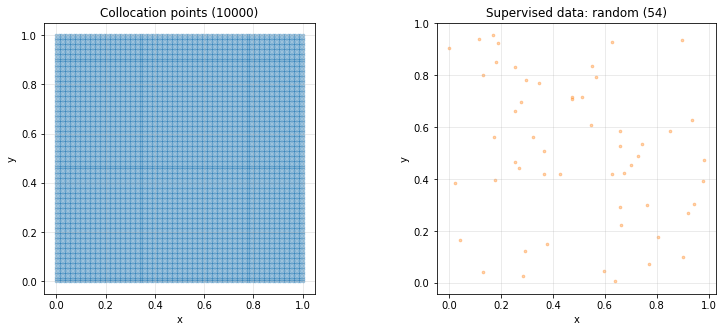

In [14]:
plot_points()


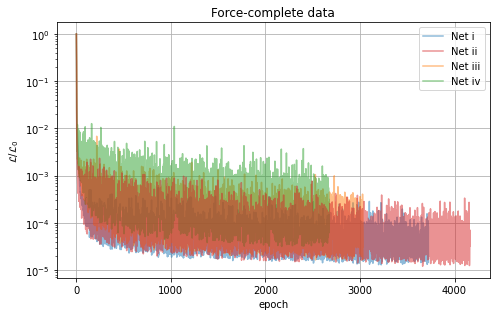

In [ ]:
plot_architecture_comparison()

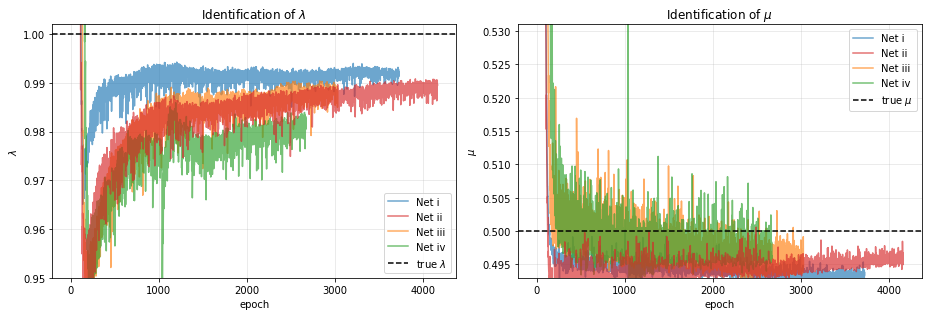

In [ ]:
plot_material_parameters()

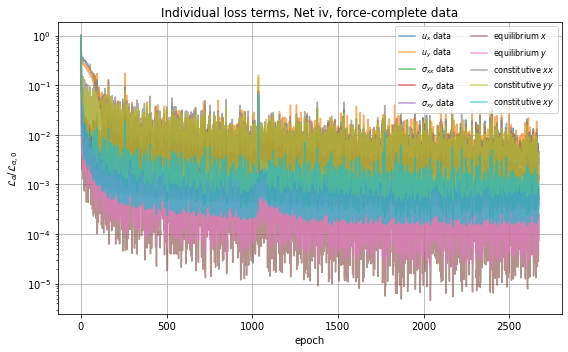

In [ ]:
plot_individual_loss_terms()

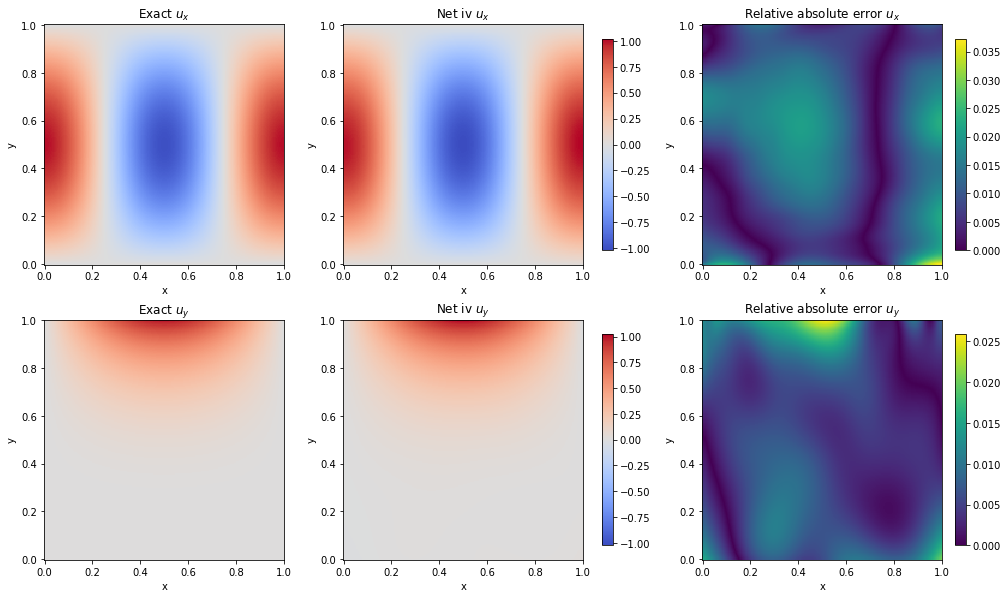

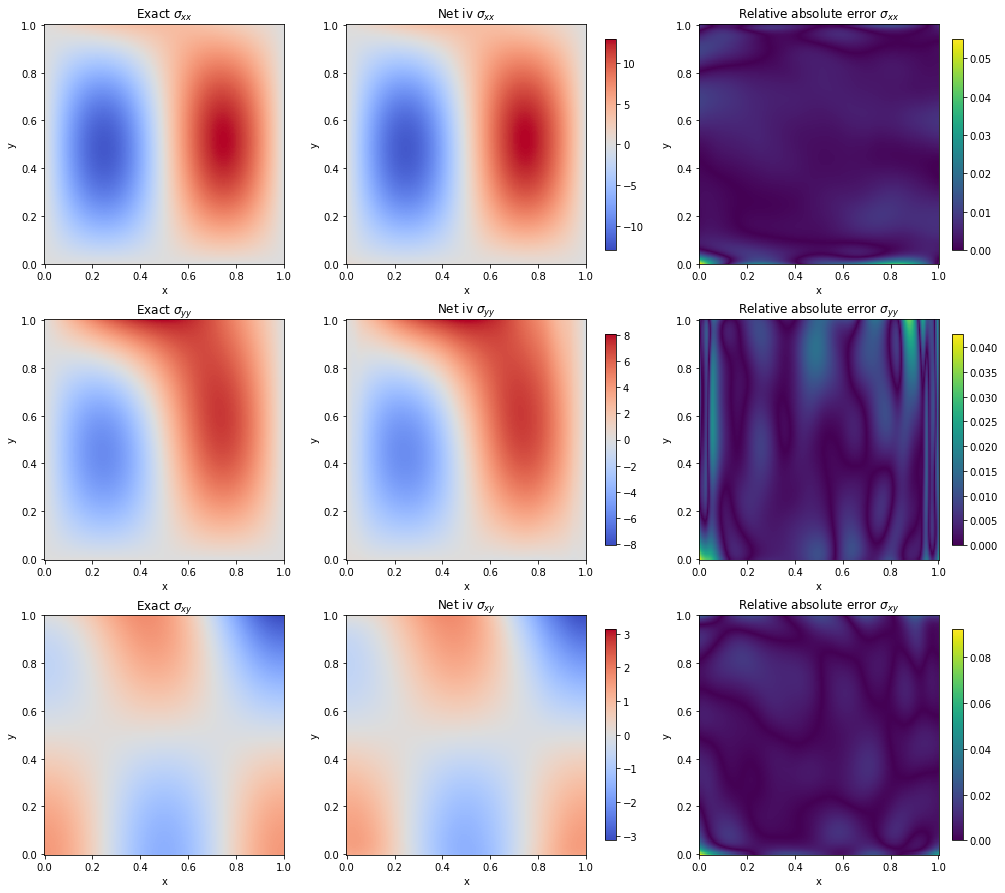

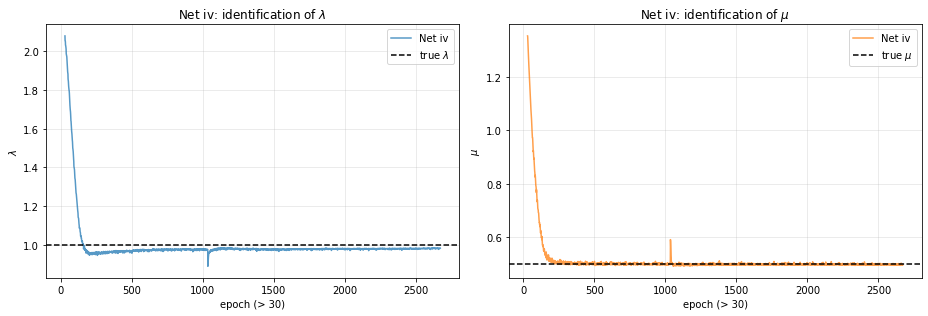

In [ ]:
plot_displacement_comparison()
plot_stress_comparison()
plot_selected_material_parameters()